## Examen Primer Parcial
### Data Science 8CC2
### Universidad Autónoma de Chihuahua
### Facultad de Ingenieria
### Ingenieria en ciencias de la computación
### Docente: Olanda Prieto Ordaz
### Fecha de entrega: Viernes 12 de septiembre del 2025
*Allan Hall Solorio 358909*

## Introducción

En esta práctica, utilizando una base de datos de Kaggle sobre precios de coches (car_price), se llevo a cabo un proceso completo de Data Science para abordar la tarea de predicción de precios mediante modelos de Machine Learning de regresión lineal.

Los pasos principales que se realizaron fueron:

1.  **Obtención de los datos:** Descarga del dataset directamente desde Kaggle.
2.  **Partición de los datos:** División del dataset en conjuntos de entrenamiento y prueba para la evaluación del modelo.
3.  **Exploración de los datos:** Análisis inicial para comprender la estructura de los datos, identificar posibles problemas (como valores faltantes o inconsistencias) y visualizar distribuciones de características clave.
4.  **Preprocesamiento de los datos:** Limpieza y transformación de los datos, incluyendo el manejo de valores inconsistentes, la codificación de variables categóricas y el escalado de características numéricas para preparar los datos para los modelos de Machine Learning.
5.  **Implementación de modelos de Regresión Lineal:** Entrenamiento y evaluación de un modelo de Regresión Lineal simple utilizando validación cruzada.
6.  **Implementación y optimización de modelo Ridge:** Implementación de un modelo de Regresión Ridge y uso de Grid Search para encontrar los mejores hiperparámetros, evaluando su rendimiento también con validación cruzada.
7.  **Evaluación del modelo final:** Evaluación del mejor modelo obtenido en el conjunto de prueba no visto para obtener métricas finales de rendimiento.

A través de este proceso, exploramos las capacidades de los modelos lineales para la predicción de precios y sentamos las bases para futuras mejoras en el modelo.

In [1]:
# 1. Obtención de los datos
!pip install kaggle
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download deepcontractor/car-price-prediction-challenge -p /content/dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge
License(s): CC0-1.0
  0% 0.00/429k [00:00<?, ?B/s]
100% 429k/429k [00:00<00:00, 679MB/s]


In [3]:
#2. Particionar en Train y test
import pandas as pd
from sklearn.model_selection import train_test_split

# cargar el dataset
df = pd.read_csv('/content/dataset/car_price_prediction.csv')

# Definir caracteristicas (X) y target (y) - asumiendo que'Price' es el target disponible
X = df.drop('Price', axis=1)
y = df['Price']

# Dividir los datos en Train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (15389, 17)
Testing set shape: (3848, 17)


In [4]:
# crear una copia de train (esto se hace como buena practica)
df = X_train.copy()
df['Price'] = y_train

In [5]:
# 3. Exploración de los datos
data = pd.DataFrame(df)
data

,ID,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Price
7808,45648994,779,TOYOTA,Camry,2013,Sedan,Yes,Hybrid,2.5,225510 km,4.0,Automatic,Front,04-May,Left wheel,White,12,314
16766,45793654,1282,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,76198 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4,6429
7285,45766234,1399,MERCEDES-BENZ,E 350,2010,Sedan,Yes,Diesel,3.5,189530 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12,12388
15712,45810582,642,CHEVROLET,Orlando,2012,Jeep,Yes,Diesel,2,218525 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4,14834
16562,45767031,-,BMW,X5,2000,Jeep,Yes,LPG,3,25000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Silver,6,10036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,45730512,880,SSANGYONG,Actyon,2018,Jeep,Yes,Petrol,1.6,11953 km,4.0,Automatic,Front,04-May,Left wheel,Red,4,44752
11964,45648818,609,TOYOTA,Camry,2018,Sedan,Yes,Hybrid,2.5,35058 km,4.0,Automatic,Front,04-May,Left wheel,White,12,18817
5390,45648475,915,BMW,X5,2014,Jeep,Yes,Diesel,3,110715 km,6.0,Automatic,4x4,04-May,Left wheel,White,0,16621
860,45805255,-,BMW,325,2005,Sedan,Yes,Petrol,2.5,162000 km,6.0,Tiptronic,Rear,04-May,Right-hand drive,White,12,12544


Aqí podemos observar que la columna "Levy" (que es un tipo de impuesto) tiene algunos campos con el caracter (-) para indicar que no posee dicha caracteristica, además de que en la columna "mileage" los datos númericos poseen además la unidad (km) y eso nos afectaria así como en "engine volume" que en algunos casos tiene la leyenda "turbo"

En este caso para "Levy" se puede llenar con valores como NaN, pero como no lo tiene, se pueden llenar con el promedio, o directamente se puede eliminar la columna, si es un dato irrelevante. Esto haria más fácil el análisis de los datos.

Para las otras columnas se puede usar "str.replace" para reemplazarlo por espacio en blanco

In [6]:
# eliminar la columna de Levy (se considero irrelevante para el modelo)
df = df.drop('Levy', axis=1)

In [7]:
df.describe()

,ID,Prod. year,Cylinders,Airbags,Price
count,1.538900e+04,15389.000000,15389.000000,15389.000000,1.538900e+04
mean,4.557428e+07,2010.944181,4.579635,6.572942,1.894767e+04
std,9.383112e+05,5.637089,1.194924,4.326692,2.128972e+05
min,2.074688e+07,1939.000000,1.000000,0.000000,1.000000e+00
25%,4.570061e+07,2009.000000,4.000000,4.000000,5.331000e+03
50%,4.577250e+07,2012.000000,4.000000,6.000000,1.317200e+04
75%,4.580209e+07,2015.000000,4.000000,12.000000,2.226600e+04
max,4.581665e+07,2020.000000,16.000000,16.000000,2.630750e+07


`df.describe()` es un método de pandas que genera estadísticas descriptivas de las columnas numéricas en un DataFrame. Esto incluye:

*   **count:** El número de valores no nulos.
*   **mean:** El promedio de los valores.
*   **std:** La desviación estándar, que mide la dispersión de los datos.
*   **min:** El valor mínimo.
*   **25%:** El primer cuartil (percentil 25).
*   **50%:** La mediana (percentil 50).
*   **75%:** El tercer cuartil (percentil 75).
*   **max:** El valor máximo.

Esta información es muy útil para obtener un resumen rápido de la distribución y el rango de los datos numéricos en tu dataset.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15389 entries, 7808 to 15795
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                15389 non-null  int64  
 1   Manufacturer      15389 non-null  object 
 2   Model             15389 non-null  object 
 3   Prod. year        15389 non-null  int64  
 4   Category          15389 non-null  object 
 5   Leather interior  15389 non-null  object 
 6   Fuel type         15389 non-null  object 
 7   Engine volume     15389 non-null  object 
 8   Mileage           15389 non-null  object 
 9   Cylinders         15389 non-null  float64
 10  Gear box type     15389 non-null  object 
 11  Drive wheels      15389 non-null  object 
 12  Doors             15389 non-null  object 
 13  Wheel             15389 non-null  object 
 14  Color             15389 non-null  object 
 15  Airbags           15389 non-null  int64  
 16  Price             15389 non-null  int64  


`df.info()` es un método muy útil en pandas que proporciona un resumen conciso de un DataFrame. Muestra la siguiente información:

*   El tipo de índice del DataFrame.
*   El número de columnas.
*   Las etiquetas de las columnas (nombres de las columnas).
*   El número de valores no nulos en cada columna (`Non-Null Count`). Esto es muy importante para identificar columnas con valores faltantes.
*   El tipo de dato (`Dtype`) de cada columna (por ejemplo, `int64`, `float64`, `object`).
*   La cantidad de memoria que está utilizando el DataFrame.

Esta información te ayuda a comprender rápidamente la estructura de tus datos, identificar los tipos de datos y ver si hay valores faltantes que necesiten ser tratados.

In [9]:
# obtener la cantidad de datos faltantes (vacios) en cada una de las columnas del dataset,
# en caso de que hayan datos faltantes, se deben realizar algunas estrategias para tratar esos datos
df.isnull().sum()

,0
ID,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0
Mileage,0
Cylinders,0


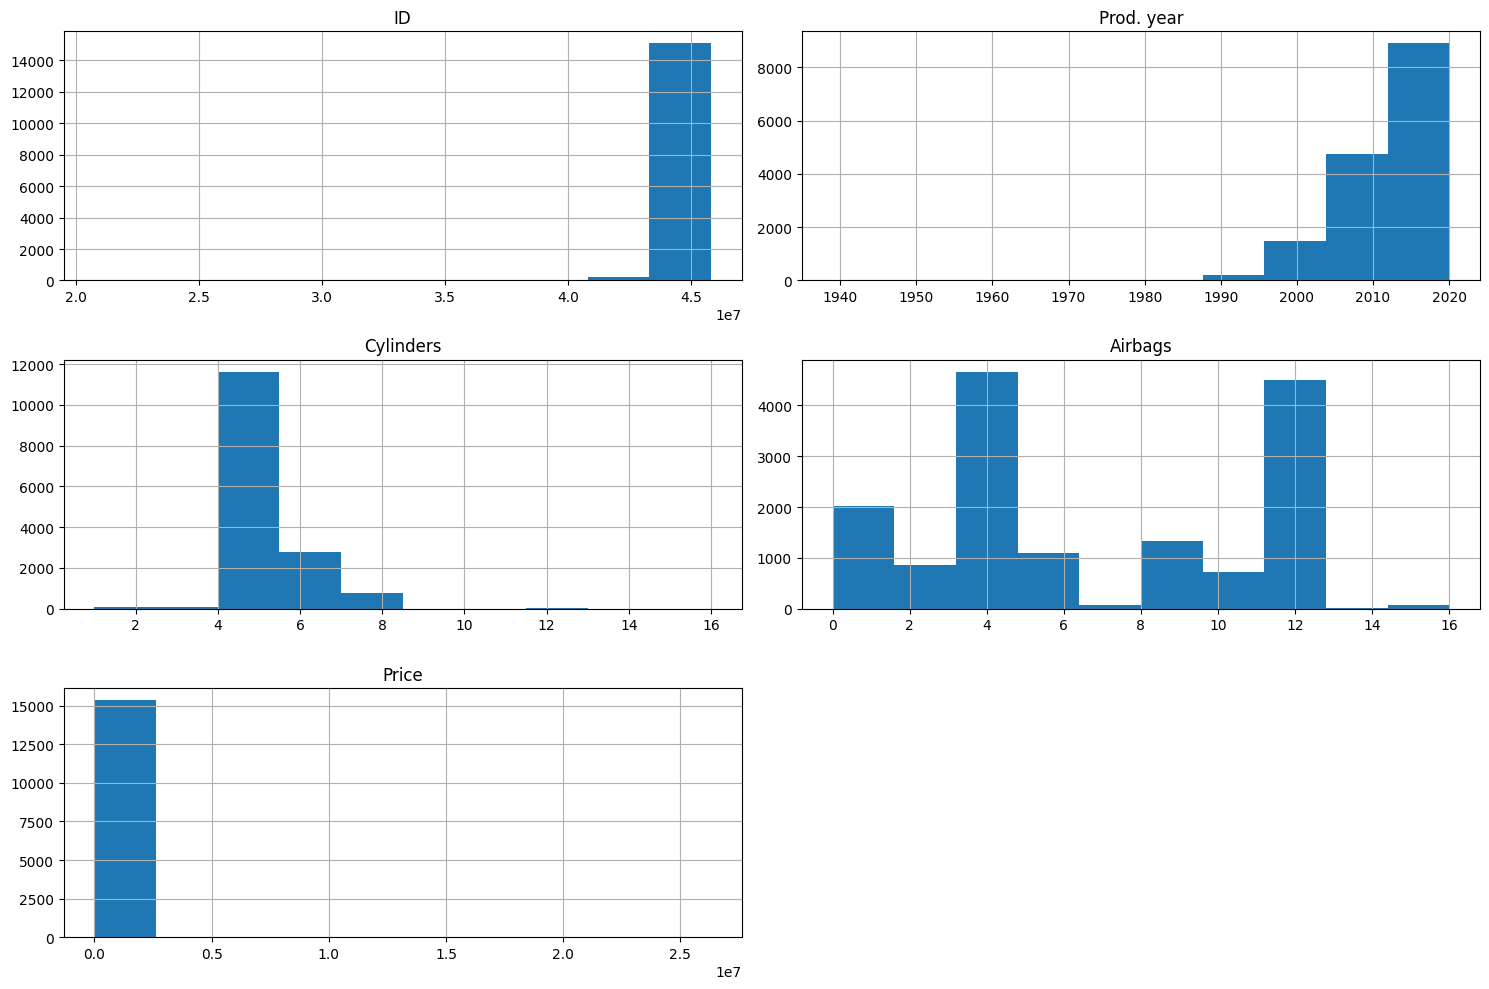

In [10]:
# 4. obtener gráficas y matriz de correlación
import matplotlib.pyplot as plt

# Seleccionar solo categorias numericas para el histograma
df_numeric = df.select_dtypes(include=['int64', 'float64'])

df_numeric.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

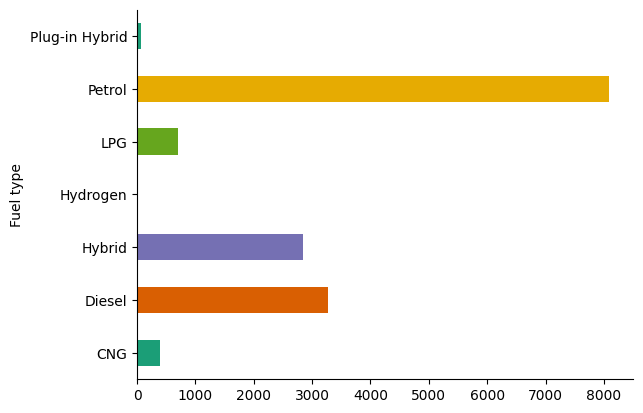

In [11]:
# @title Tipo de combustible

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Fuel type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

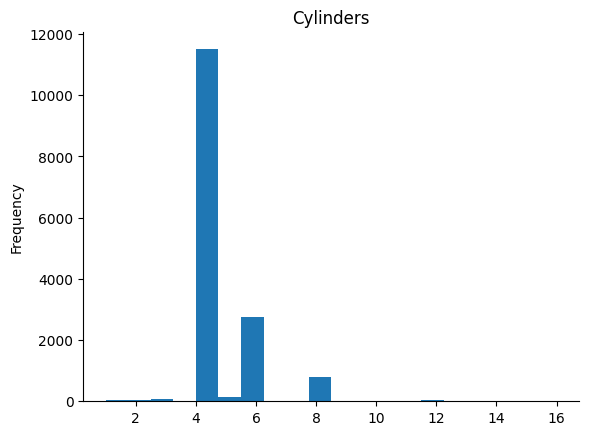

In [12]:
# @title Cilindros

from matplotlib import pyplot as plt
data['Cylinders'].plot(kind='hist', bins=20, title='Cylinders')
plt.gca().spines[['top', 'right',]].set_visible(False)

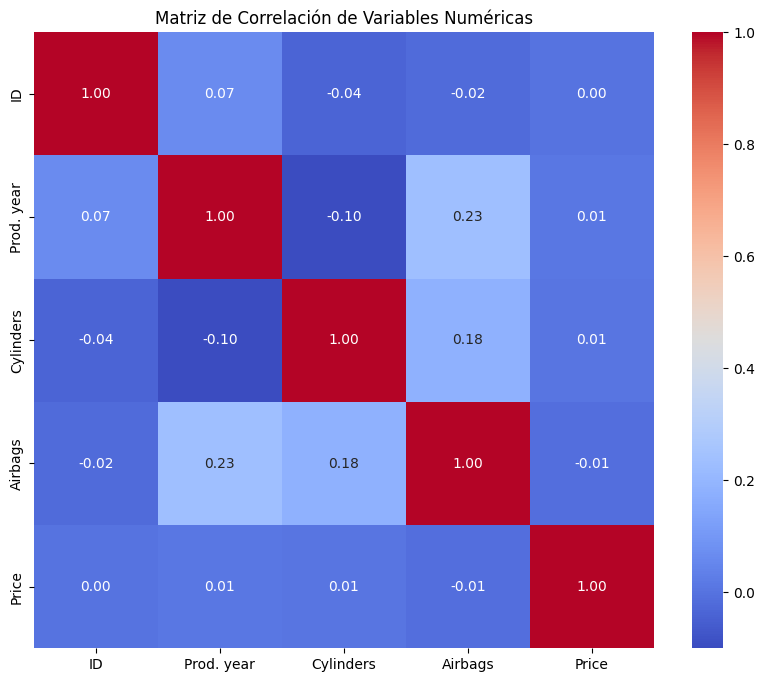

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas para la matriz de correlación
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualizar la matriz de correlación usando un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [49]:
# 5. Transformación de los datos por medio de un pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Identificar columnas categóricas y numéricas (excluyendo 'ID')
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.drop('ID')


# Crear un ColumnTransformer para preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Mantener la columna 'ID'
)

# Crear un pipeline que incluya el preprocesador y un modelo de regresión lineal
linear_regression_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                             ('regressor', LinearRegression())])

En la celda anterior , se definió un `ColumnTransformer` como parte del pipeline de preprocesamiento. Este transformador se encarga de preparar los datos antes de pasarlos al modelo.

Aquí se explica cómo se trataron los datos no numéricos:

1.  **Columnas Categóricas:** Las columnas con tipo de dato 'object' (que representan categorías como 'Manufacturer', 'Category', 'Fuel type', etc.) fueron identificadas y se les aplicó `OrdinalEncoder` dentro del `ColumnTransformer`. `OrdinalEncoder` convierte estas categorías en valores numéricos, lo cual es necesario para los modelos de Machine Learning. Se usó `handle_unknown='ignore'` (o 'use_encoded_value' en la implementación de la celda) para manejar posibles categorías que solo aparezcan en el conjunto de prueba.

2.  **Columna 'Mileage':** Esta columna originalmente contenía texto (como "km"). Antes de aplicar el `ColumnTransformer`, se eliminó el texto " km" y la columna se convirtió al tipo de dato numérico flotante (`float`) en un paso previo del preprocesamiento. Aunque esta conversión específica ocurrió antes del `ColumnTransformer` en el flujo actual, es parte del proceso de manejo de datos no numéricos para hacerla utilizable por los escaladores y modelos.

3.  **Columna 'Engine volume':** Esta columna también contenía texto (como "turbo") y fue tratada como una columna categórica debido a su tipo de dato 'object'. Por lo tanto, fue incluida en el proceso de codificación ordinal dentro del `ColumnTransformer`, convirtiendo sus diferentes valores (incluidos los que tenían " turbo") a representaciones numéricas.

Al aplicar este `ColumnTransformer`, todas estas transformaciones se ejecutan de manera automática y consistente en las columnas especificadas, preparando los datos para el entrenamiento del modelo.

In [50]:
# Mostrar el DataFrame completo después de la transformación
print("DataFrame de entrenamiento después del preprocesamiento y con la columna 'Price':")
display(data_transformed)

DataFrame de entrenamiento después del preprocesamiento y con la columna 'Price':


,num__Manufacturer,num__Model,num__Prod. year,num__Category,num__Leather interior,num__Fuel type,num__Engine volume,num__Mileage,num__Cylinders,num__Gear box type,num__Drive wheels,num__Doors,num__Wheel,num__Color,num__Airbags,remainder__ID,Price
7808,1.411369,-1.041618,0.364707,0.978136,0.612072,-0.785166,0.304563,0.068564,-0.485097,-0.597371,0.150973,0.150671,-0.286852,1.159130,1.254361,45648994.0,314
16766,-1.416428,-0.986547,-0.699707,-0.814985,0.612072,-1.337428,-0.357347,1.528222,-0.485097,-0.597371,0.150973,0.150671,-0.286852,0.785523,-0.594687,45793654.0,6429
7285,0.141746,-0.628585,-0.167500,0.978136,0.612072,-1.337428,1.429811,-0.210164,1.188704,-0.597371,-1.614469,0.150671,-0.286852,-1.269313,1.254361,45766234.0,12388
15712,-1.416428,0.555445,0.187305,-0.814985,0.612072,-1.337428,-0.357347,0.026126,-0.485097,-0.597371,0.150973,0.150671,-0.286852,-0.148493,-0.594687,45810582.0,14834
16562,-1.589559,1.632087,-1.941523,-0.814985,0.612072,0.319356,0.966474,0.213168,1.188704,1.633925,-1.614469,0.150671,-0.286852,0.785523,-0.132425,45767031.0,10036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.180529,-1.504216,1.251718,-0.814985,0.612072,0.871618,-0.886876,-1.164233,-0.485097,-0.597371,0.150973,0.150671,-0.286852,0.598720,-0.594687,45730512.0,44752
11964,1.411369,-1.041618,1.251718,0.978136,0.612072,-0.785166,0.304563,0.622354,-0.485097,-0.597371,0.150973,0.150671,-0.286852,1.159130,1.254361,45648818.0,18817
5390,-1.589559,1.632087,0.542109,-0.814985,0.612072,-1.337428,0.966474,-1.317743,1.188704,-0.597371,-1.614469,0.150671,-0.286852,1.159130,-1.519210,45648475.0,16621
860,-1.589559,-1.884207,-1.054511,0.978136,0.612072,0.871618,0.304563,-0.514041,1.188704,1.633925,1.916414,0.150671,3.486114,1.159130,1.254361,45805255.0,12544


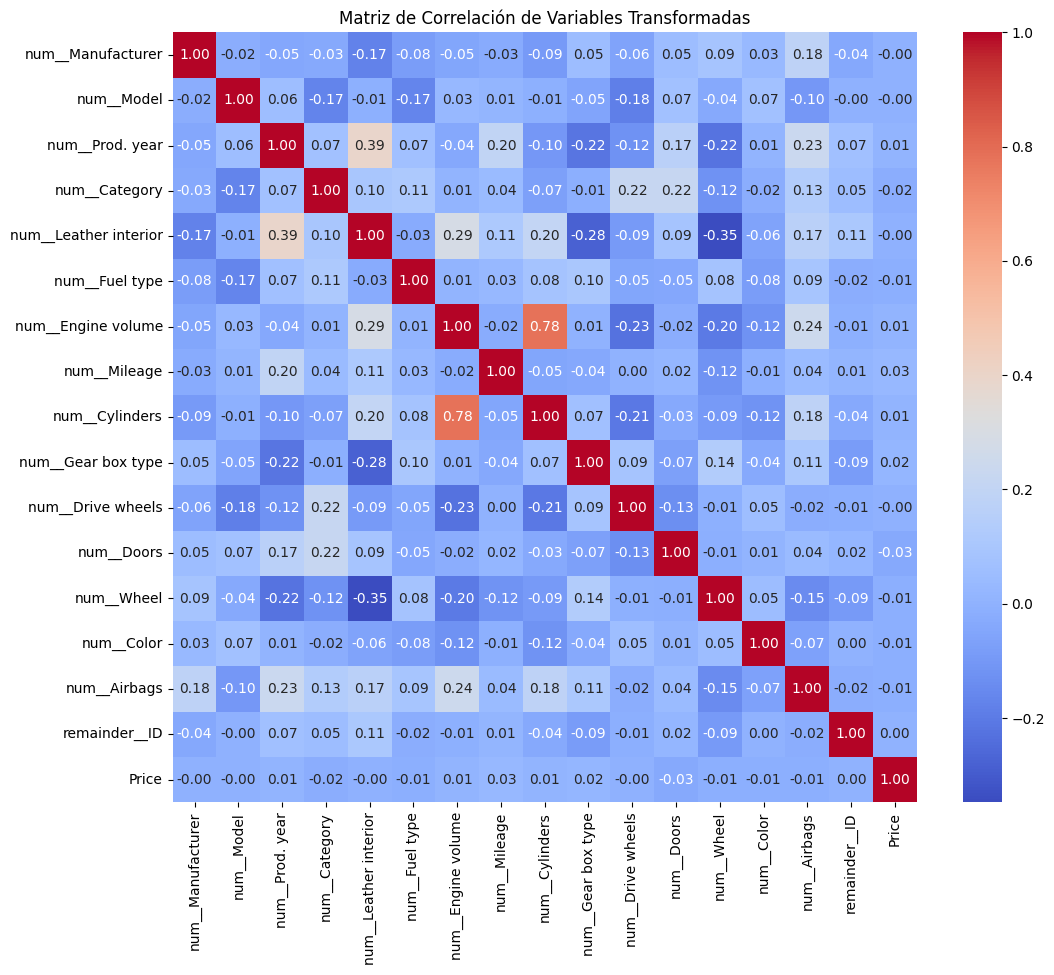

In [51]:
# Mostrar la matriz de correlación de los datos transformados
import matplotlib.pyplot as plt
import seaborn as sns

if 'data_transformed' in locals():
    # Calcular la matriz de correlación
    correlation_matrix_transformed = data_transformed.corr()

    # Visualizar la matriz de correlación usando un heatmap
    plt.figure(figsize=(12, 10)) # Ajustar tamaño si hay muchas columnas
    sns.heatmap(correlation_matrix_transformed, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación de Variables Transformadas')
    plt.show()
else:
    print("Error: data_transformed no está disponible. Por favor, ejecuta las celdas de preprocesamiento primero.")

Ahora que hemos aplicado el preprocesamiento a los datos, incluyendo la codificación de las variables categóricas a valores numéricos y el escalado, es posible calcular la matriz de correlación para **todas** las características (incluyendo las que originalmente no eran numéricas) y la variable objetivo (`Price`).

Esta matriz de correlación nos ayuda a visualizar la relación lineal entre cada par de variables transformadas.

*   Los valores cercanos a **1** o **-1** indican una fuerte correlación lineal (positiva o negativa).
*   Los valores cercanos a **0** indican una correlación lineal débil o inexistente.

Observar esta matriz nos permite identificar qué características transformadas tienen una relación más fuerte con el precio del coche y entre sí.

In [39]:
# 6 Implementar modelo de Regresión Lineal
# a) Un modelo de RL sin ajustar sus parámetros. Utilizar la estrategia de Cross Validation de 10 particiones.
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calcular puntuaciones R-cuadrado mediante validación cruzada
cv_r2_scores_lr_pipeline = cross_val_score(linear_regression_pipeline, X_train, y_train, cv=10, scoring='r2')

# Calcular el error cuadrático medio negativo mediante validación cruzada
cv_mse_scores_lr_pipeline = cross_val_score(linear_regression_pipeline, X_train, y_train, cv=10, scoring='neg_mean_squared_error')

# Calculate el RMSE
cv_rmse_scores_lr_pipeline = np.sqrt(-cv_mse_scores_lr_pipeline)

# Imprima la media y la desviación estándar de las puntuaciones R-cuadrado
print("Resultados de la validación cruzada del Pipeline de Regresión Lineal (R-squared):")
print(f"Media: {cv_r2_scores_lr_pipeline.mean():.4f}")
print(f"Desviación estándar: {cv_r2_scores_lr_pipeline.std():.4f}")

# Print the mean and standard deviation of RMSE scores
print("\nResultados de la validación cruzada del Pipeline de Regresión Lineal (RMSE):")
print(f"Media: {cv_rmse_scores_lr_pipeline.mean():.4f}")
print(f"Desviación estándar: {cv_rmse_scores_lr_pipeline.std():.4f}")

Resultados de la validación cruzada del Pipeline de Regresión Lineal (R-squared):
Media: -0.1735
Desviación estándar: 0.1154

Resultados de la validación cruzada del Pipeline de Regresión Lineal (RMSE):
Media: 86551.8730
Desviación estándar: 194683.0956


Interpretacion de los Resultados

Media R-squared: -0.1735
      
  - Este valor indica que el modelo de Regresión Lineal, en promedio a través de las 10 particiones de validación cruzada, explica un porcentaje negativo de la varianza en el precio de los coches.
  - En términos prácticos, un R-squared negativo significa que el modelo se desempeña peor que un modelo muy simple que simplemente predice el precio promedio de los coches para todas las instancias. Esto es una clara señal de que el modelo lineal no se ajusta bien a los datos.
    
  Desviación estándar R-squared: 0.1154

  - Esta desviación estándar relativamente baja indica que el rendimiento del modelo (medido por R-squared) fue algo consistente entre las diferentes particiones de la validación cruzada, aunque consistentemente pobre.
    
  Media RMSE: 86551.8730
        
  - El RMSE mide el error promedio en las predicciones en la misma unidad que la variable objetivo (el precio).
  - Una media de 86551.8730 significa que, en promedio, las predicciones de tu modelo se desvían de los precios reales por una cantidad muy grande. Un valor de RMSE tan alto sugiere que el modelo no está haciendo buenas predicciones.
    
  Desviación estándar RMSE: 194683.0956
        
  - Esta desviación estándar es bastante alta en comparación con la media del RMSE. Esto sugiere que hubo una variación considerable en los errores de predicción entre las diferentes particiones de la validación cruzada. Algunas particiones podrían haber tenido errores mucho mayores que otras, lo que podría indicar la presencia de valores atípicos o subconjuntos de datos particularmente difíciles de predecir.

Como observamos anteriormente, el modelo estándar de Regresión Lineal (`LinearRegression`) no tiene hiperparámetros típicos que podamos ajustar con técnicas como Grid Search para mejorar su rendimiento. Es un modelo simple que busca la mejor línea recta que se ajuste a los datos.

Sin embargo, existen variantes de la regresión lineal que sí tienen parámetros ajustables y pueden ofrecer un mejor rendimiento, especialmente en presencia de multicolinealidad (cuando las características están fuertemente correlacionadas entre sí) o ruido en los datos. Uno de estos modelos es la **Regresión Ridge**.

**¿Por qué usar Regresión Ridge y Grid Search?**

La Regresión Ridge es un tipo de regresión lineal que incluye un término de regularización. Este término añade una penalización a los coeficientes del modelo, lo que ayuda a reducir su magnitud. El objetivo principal de esta regularización es prevenir el sobreajuste (overfitting) y mejorar la capacidad de generalización del modelo a datos no vistos.

El parámetro clave en la Regresión Ridge es **`alpha`** (o lambda en algunas notaciones). Este parámetro controla la fuerza de la regularización:

*   Un `alpha` muy grande penaliza fuertemente los coeficientes, lo que puede llevar a un modelo demasiado simple (subajuste).
*   Un `alpha` igual a 0 hace que la Regresión Ridge sea equivalente a la Regresión Lineal simple.
*   Valores intermedios de `alpha` encuentran un equilibrio entre ajustar los datos de entrenamiento y mantener los coeficientes pequeños.

Aquí es donde Grid Search se vuelve útil. A diferencia de la Regresión Lineal simple, la Regresión Ridge tiene el hiperparámetro `alpha` que **sí podemos ajustar**. Utilizando Grid Search, exploramos una cuadrícula de posibles valores para `alpha` y, mediante validación cruzada, encontramos el valor que resulta en el mejor rendimiento del modelo en los datos de entrenamiento.

Por lo tanto, se decidíon implementar el modelo de Regresión Ridge y usar Grid Search específicamente para encontrar un valor óptimo para su parámetro `alpha`, con la esperanza de que esta regularización ayude al modelo a capturar mejor las relaciones en los datos y a obtener un mejor rendimiento en comparación con la Regresión Lineal simple sin regularización. Aunque los resultados iniciales mostraron solo una mejora marginal, el enfoque de usar un modelo con hiperparámetros ajustables como Ridge es una práctica estándar para intentar optimizar el rendimiento en tareas de regresión.

In [40]:
# b) Otro modelo de RL y buscar los mejores parámetros con un GridSearch/RandomSearch
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Crear una pipeline con el preprocesador y un modelo Ridge
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Ridge())])

# Definir la cuadrícula de hiperparámetros para alfa para el modelo Ridge
param_grid_ridge = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

# Inicializar GridSearchCV con ridge_pipeline y el hiperparámetro grid
grid_search_ridge = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=10, scoring='r2')

# Ajustar el objeto GridSearchCV a los datos de train
print("Realizando Grid Search para el Pipeline de Regresión Ridge...")
grid_search_ridge.fit(X_train, y_train)
print("Grid Search completado.")

Realizando Grid Search para el Pipeline de Regresión Ridge...
Grid Search completado.


In [41]:
import numpy as np
from sklearn.model_selection import cross_val_score
# d)
# obtener los mejores parametros encontrados por GridSearchCV
print(f"\nMejores parámetros encontrados por Grid Search para Ridge Pipeline: {grid_search_ridge.best_params_}")

# Obtener el mejor puntaje de cross-validation (R-cuadrado) encontrado por GridSearchCV
print(f"Mejor puntuación de validación cruzada (R-squared) de Grid Search para Ridge Pipeline: {grid_search_ridge.best_score_:.4f}")

# Obtener el mejor modelo del grid search
best_ridge_pipeline = grid_search_ridge.best_estimator_

# Realizar una cross validation en la mejor pipeline de Ridge
cv_r2_scores_best_ridge_pipeline = cross_val_score(best_ridge_pipeline, X_train, y_train, cv=10, scoring='r2')
cv_mse_scores_best_ridge_pipeline = cross_val_score(best_ridge_pipeline, X_train, y_train, cv=10, scoring='neg_mean_squared_error')

# Calcular el RMSE
cv_rmse_scores_best_ridge_pipeline = np.sqrt(-cv_mse_scores_best_ridge_pipeline)

# Obtener la media y la desviación estándar de las puntuaciones R-cuadrado de cross-validation
print("\nResultados de la validación cruzada para el mejor Ridge Pipeline (R-squared):")
print(f"Media: {cv_r2_scores_best_ridge_pipeline.mean():.4f}")
print(f"Desviación estándar: {cv_r2_scores_best_ridge_pipeline.std():.4f}")

# Obtener la media y la desviación estándar de las puntuaciones RMSE de cross-validation
print("\nResultados de la validación cruzada para el mejor Ridge Pipeline (RMSE):")
print(f"Media: {cv_rmse_scores_best_ridge_pipeline.mean():.4f}")
print(f"Desviación estándar: {cv_rmse_scores_best_ridge_pipeline.std():.4f}")


Mejores parámetros encontrados por Grid Search para Ridge Pipeline: {'regressor__alpha': 100.0}
Mejor puntuación de validación cruzada (R-squared) de Grid Search para Ridge Pipeline: -0.1689

Resultados de la validación cruzada para el mejor Ridge Pipeline (R-squared):
Media: -0.1689
Desviación estándar: 0.1131

Resultados de la validación cruzada para el mejor Ridge Pipeline (RMSE):
Media: 86512.4240
Desviación estándar: 194696.0995


Interpretacion de los Resultados:
  
Mejores parámetros encontrados por Grid Search para Ridge Pipeline: {'regressor__alpha': 100.0}
    
  - Esto indica que, dentro de la cuadrícula de valores de alpha que especificaste ([0.001, 0.01, 0.1, 1.0, 10.0, 100.0]), el valor de alpha que resultó en el mejor rendimiento (medido por R-squared) durante la validación cruzada fue 100.0. Este es el hiperparámetro de regularización que el Grid Search consideró óptimo para este modelo y conjunto de datos.
    
Mejor puntuación de validación cruzada (R-squared) de Grid Search para Ridge Pipeline: -0.1689
        
- Esta es la puntuación R-squared obtenida por el modelo Ridge utilizando alpha = 100.0 en el fold de validación cruzada donde alcanzó su mejor rendimiento.
    
    
Resultados de la validación cruzada para el mejor Ridge Pipeline (R-squared): Media: -0.1689
            
            
- La media del R-squared a través de las 10 particiones de validación cruzada para el modelo Ridge con alpha = 100.0 es -0.1689. Al igual que con el modelo lineal simple, un R-squared negativo indica un rendimiento pobre, peor que predecir la media.
        
Desviación estándar: 0.1131
- Una desviación estándar relativamente baja sugiere que el rendimiento fue algo consistente a través de las diferentes particiones de los datos.
    
    
  Resultados de la validación cruzada para el mejor Ridge Pipeline (RMSE):
        
  Media: 86512.4240
  - La media del RMSE para el mejor modelo Ridge es 86512.4240. Este valor, aunque ligeramente menor que el del modelo lineal simple, sigue siendo muy alto, indicando que las predicciones tienen un error promedio considerable.
        
  Desviación estándar: 194696.0995
    - Una desviación estándar alta para el RMSE sugiere que hay una variabilidad significativa en el tamaño de los errores de predicción entre las diferentes particiones de la validación cruzada.

Comparación y Próximo Paso:

Comparando estos resultados con los del modelo de Regresión Lineal simple (Media R-squared: -0.1735, Media RMSE: 86551.8730), el modelo Ridge con alpha=100.0 muestra una mejora marginal (el R-squared es un poco menos negativo y el RMSE es un poco menor). Aunque la mejora es pequeña y el rendimiento general sigue siendo bajo (con R-squared negativo), dentro de los modelos lineales probados, este modelo Ridge con alpha=100.0 es el que tuvo el mejor desempeño en la validación cruzada.

Por lo tanto, este mejor modelo de Regresión Ridge (con alpha=100.0) es el que utilizaremos para el paso final de evaluarlo en el conjunto de prueba (X_test), para obtener las métricas de rendimiento finales en datos completamente nuevo

In [42]:
7# Realizar la evaluación del mejor modelo utilizando el conjunto de Test.
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Usar el best_ridge_pipeline para hacer predicciones en el X_test dataset
y_pred_ridge_test = best_ridge_pipeline.predict(X_test)

# Calcular el puntaje R-squared ente y_test y y_pred_ridge_test
r2_test_ridge = r2_score(y_test, y_pred_ridge_test)

# Calcular el error cuadrático medio (MSE) entre y_test y y_pred_ridge_test
mse_test_ridge = mean_squared_error(y_test, y_pred_ridge_test)

# Calcular el error cuadrático medio (RMSE) tomando la raíz cuadrada del MSE
rmse_test_ridge = np.sqrt(mse_test_ridge)

# Obtener los puntajes R-cuadrado, MSE y RMSE calculados para el conjunto de prueba
print("Métricas de Evaluación del mejor Ridge Pipeline en el conjunto de prueba:")
print(f"R-squared en el conjunto de prueba: {r2_test_ridge:.4f}")
print(f"Mean Squared Error (MSE) en el conjunto de prueba: {mse_test_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE) en el conjunto de prueba: {rmse_test_ridge:.2f}")

Métricas de Evaluación del mejor Ridge Pipeline en el conjunto de prueba:
R-squared en el conjunto de prueba: -0.2126
Mean Squared Error (MSE) en el conjunto de prueba: 377826721.66
Root Mean Squared Error (RMSE) en el conjunto de prueba: 19437.77


## Resumen:

### Hallazgos Clave del Análisis de Datos

* El flujo de regresión lineal obtuvo un R-cuadrado medio de validación cruzada de -0,1735 con una desviación estándar de 0,1154 y un RMSE medio de 86551,87 con una desviación estándar de 194683,10.
* Mediante la búsqueda en grid search con cross validation de 10 pasos, se determinó que el alfa óptimo para el flujo de Ridge era 100,0.
* El mejor flujo de Ridge, al evaluarse con cross validation de 10 pasos, mostró un R-cuadrado medio de -0,1689 con una desviación estándar de 0,1131 y un RMSE medio de 86512,42 con una desviación estándar de 194696,10.
* En el conjunto de pruebas no visto, la mejor pipeline Ridge arrojó un R cuadrado de -0,2126 y un RMSE de 19437,77.

### 8) Conclusion

* Tanto los modelos de regresión lineal como los de Ridge, incluso después del preprocesamiento y el ajuste de hiperparámetros, muestran valores R-cuadrado negativos tanto en el conjunto de train (mediante cross validation) como en el de test. Esto indica que los modelos tienen un rendimiento inferior al de la simple predicción del promedio de la variable objetivo, lo que sugiere que los modelos lineales podrían no ser adecuados para este conjunto de datos o que las características actuales no son lo suficientemente predictivas.
* Se deberían explorar modelos más complejos (p. ej., modelos basados ​​en árboles, métodos de conjunto) o considerar la ingeniería de características para mejorar potencialmente el rendimiento del modelo.

Este proyecto ha servido como una valiosa experiencia práctica en el proceso de Data Science. Desde la obtención y exploración inicial de los datos, pasando por el crucial paso del preprocesamiento (manejo de valores faltantes/inconsistentes, codificación de variables categóricas, escalado de características), hasta la implementación y evaluación de modelos de Machine Learning. Aunque los resultados iniciales con modelos lineales no fueron los esperados, esto subraya un aspecto fundamental del Data Science: el proceso es iterativo y requiere experimentación con diferentes enfoques para encontrar el modelo más adecuado para un problema dado.

La utilidad del Data Science en la actualidad se manifiesta precisamente en la capacidad de abordar problemas complejos como la predicción de precios, donde múltiples factores interjuegan. A través del análisis de datos, la aplicación de algoritmos y la evaluación rigurosa de resultados, podemos obtener insights, construir modelos predictivos y tomar decisiones informadas en diversas industrias, desde el comercio electrónico y las finanzas hasta la salud y la manufactura. Este proyecto, a pesar de los resultados iniciales, demuestra la aplicación de estas herramientas y metodologías para intentar extraer valor de los datos y abordar un problema del mundo real.


## Referencias

Aquí se listan las principales librerías de Python utilizadas en este proyecto, así como la fuente del conjunto de datos:

**Librerías:**

*   **pandas:** Utilizada para la manipulación y análisis de datos.
*   **scikit-learn:** Librería fundamental para Machine Learning, utilizada para la división de datos, preprocesamiento (escalado, codificación) y modelos de regresión.
*   **matplotlib y seaborn:** Utilizadas para la visualización de datos.
*   **numpy:** Utilizada para operaciones numéricas, especialmente en el cálculo de RMSE.

**Fuente del Conjunto de Datos:**

*   **Kaggle Dataset:** [Car Price Prediction Challenge](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge)